# Image XAI Experiment #2

이미지 XAI 출력 결과에 대한 핸들링, 고도화된 분석 방안 도출
> GradCAM 출력 가중치에 대한 정량 수치 계산, 의미 있는 데이터 드리프트 해석 도출

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
import warnings

def setup_korean_font():
    """
    시스템에 맞는 한글 폰트를 설정합니다.
    """
    system = platform.system()
    
    if system == "Darwin":  # macOS
        # macOS 기본 한글 폰트들
        korean_fonts = [
            'AppleGothic',
            'NanumGothic',
            'NanumBarunGothic',
            'Malgun Gothic',
            'Arial Unicode MS'
        ]
    elif system == "Windows":
        # Windows 기본 한글 폰트들
        korean_fonts = [
            'Malgun Gothic',
            'NanumGothic',
            'NanumBarunGothic',
            'Batang',
            'Dotum'
        ]
    else:  # Linux
        # Linux 한글 폰트들
        korean_fonts = [
            'NanumGothic',
            'NanumBarunGothic',
            'DejaVu Sans',
            'Liberation Sans'
        ]
    
    # 사용 가능한 폰트 찾기
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in korean_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            print(f"한글 폰트 '{font}' 적용 완료")
            return True
    
    # 폰트를 찾지 못한 경우 경고
    warnings.warn("적절한 한글 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.")
    return False

In [2]:
# 한글 폰트 설정
setup_korean_font()
# "-" 깨짐 현상 해결을 위해 추가
plt.rcParams['axes.unicode_minus'] = False

한글 폰트 'AppleGothic' 적용 완료


## GRAD-CAM

이미지 데이터의 영역 별 모델 가중치의 활성화 정도를 레이어 단위로 측정

> 이미지 데이터에 대한 가중치 활성화 데이터 추출 ( **Class Activation Map** )<br>
> 출력 결과에 대한 다양한 수치 계산

### Output Test

데이터 로드, 모델 출력 및 CAM 시각화 기능 테스트

* load test data & model

In [3]:
import cv2
from PIL import Image
from matplotlib import pyplot as plt
import os
from ultralytics import YOLO
import numpy as np

model_path = "../flask_webapp/models/yolo11n.pt"
model = YOLO(model_path)

print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

(256, 256, 3)


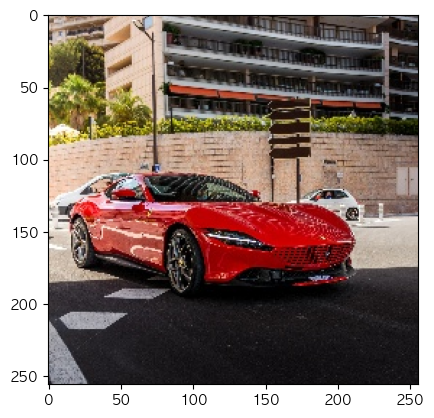

In [4]:
test_data_path = "../datadoctor_cli_test/datasets/test_data2"
test_data_list = ['car680.jpg', 'car697.jpg', 'car698.jpg', 'car702.jpg', 'car707.jpg']
test_img = Image.open(os.path.join(test_data_path, test_data_list[4]))

print(np.array(test_img).shape)
plt.imshow(test_img)
plt.show()

* get model output

In [5]:
def parse_detections(results):
    """YOLO 모델의 결과를 박스, 색상, 클래스명으로 파싱"""
    boxes = []
    colors = []
    names = []
    
    for result in results[0].boxes:
        box = result.xyxy[0].cpu().numpy()  # x1, y1, x2, y2 형식
        conf = float(result.conf)
        cls = int(result.cls)
        name = results[0].names[cls]
        
        boxes.append(box)
        colors.append(generate_color(cls))  # 클래스별 고유 색상
        names.append(f"{name} {conf:.2f}")
    
    return np.array(boxes), colors, names

def generate_color(class_id):
    """클래스 ID에 따른 고유한 색상 생성"""
    np.random.seed(class_id)
    color = np.random.randint(0, 255, size=3).tolist()
    return color

def draw_detections(boxes, colors, names, image):
    """검출 결과를 이미지에 시각화"""
    for box, color, name in zip(boxes, colors, names):
        x1, y1, x2, y2 = map(int, box)
        
        # 박스 그리기
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        
        # 텍스트 배경 그리기
        (text_w, text_h), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(image, (x1, y1-text_h-4), (x1+text_w, y1), color, -1)
        
        # 텍스트 그리기
        cv2.putText(image, name, (x1, y1-4), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
    
    return image


0: 640x640 2 cars, 69.8ms
Speed: 4.9ms preprocess, 69.8ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 640)


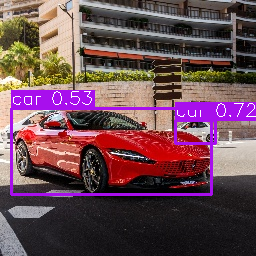

In [6]:
detect_img = np.array(test_img)

results = model(detect_img)

boxes, colors, names = parse_detections(results)
detections = draw_detections(boxes, colors, names, detect_img)

display(Image.fromarray(detections))

* get CAM output

In [7]:
import sys
import os

project_root = os.path.abspath('..')  # datadoctor_cli_test에서 상위 디렉토리로
sys.path.insert(0, project_root)

from yolo_cam.eigen_cam import EigenCAM as YOLO_EigenCAM
from yolo_cam.utils.image import show_cam_on_image as show_yolocam_on_image
from yolo_cam.utils.image import scale_cam_image as scale_yolocam_image

In [8]:
len(model.model.model)

24

In [48]:
str(model.model.model[21]).lower() == 'concat()'

True

In [53]:
target_layer = None

for idx, layers in reversed(list(enumerate(model.model.model))):
    if str(layers).lower() == "concat()":
        print(f"마지막 concat()의 인덱스: {idx}")
        print(f"마지막 concat() 모델: {models}")
        target_layer = layers
        break
else:
    print("concat()을 찾을 수 없습니다.")

마지막 concat()의 인덱스: 21
마지막 concat() 모델: Concat()



0: 640x640 3 cars, 51.5ms
Speed: 2.0ms preprocess, 51.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


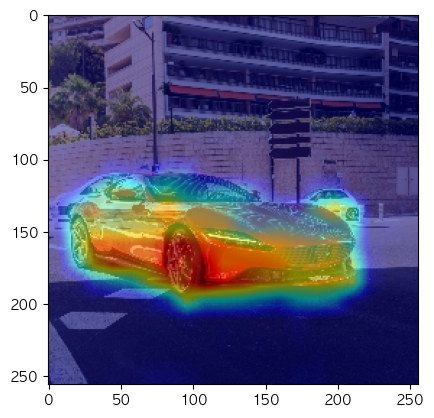

In [9]:
%matplotlib inline
import torch

rgb_img = test_img.copy()
img = np.float32(test_img) / 255

target_layers = [model.model.model[21]] # 원하는 계층 레이어 추출

cam = YOLO_EigenCAM(model, target_layers, task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_yolocam_on_image(img, grayscale_cam, use_rgb=True)

plt.imshow(cam_image)
plt.show()

### 통계 수치

평균, 최대, 합계, 표준편차 등

In [10]:
# CAM 활성도 통계 계산 (영문 키 + 한글 설명)
cam_stats = {
    'mean': ('평균', np.mean(grayscale_cam)),
    'max': ('최대값', np.max(grayscale_cam)),
    'min': ('최소값', np.min(grayscale_cam)),
    'sum': ('합계', np.sum(grayscale_cam)),
    'std': ('표준편차', np.std(grayscale_cam)),
    'median': ('중앙값', np.median(grayscale_cam)),
    'variance': ('분산', np.var(grayscale_cam)),
    'range': ('범위', np.max(grayscale_cam) - np.min(grayscale_cam)),
    'shape': ('크기', grayscale_cam.shape),
    'total_pixels': ('총 픽셀 수', grayscale_cam.size)
}

In [11]:
# 통계 출력
print("=== CAM 활성도 통계 ===")
for key, (korean_name, value) in cam_stats.items():
    if key == 'shape':
        print(f"{korean_name} ({key}) : {value}")
    elif key == 'total_pixels':
        print(f"{korean_name} ({key}) : {value:,}")
    else:
        print(f"{korean_name} ({key}) : {value:.6f}")

=== CAM 활성도 통계 ===
평균 (mean) : 0.137783
최대값 (max) : 1.000000
최소값 (min) : 0.000000
합계 (sum) : 9029.714844
표준편차 (std) : 0.239393
중앙값 (median) : 0.000000
분산 (variance) : 0.057309
범위 (range) : 1.000000
크기 (shape) : (256, 256)
총 픽셀 수 (total_pixels) : 65,536


### thresholding

임계값 기반 활성도 샘플링


=== 추가 통계 ===
상위 10% 활성도 임계값: 0.561693
상위 10% 활성도 픽셀 수: 6,554
상위 10% 활성도 비율: 10.00%
1사분위수 (Q1): 0.000000
중앙값 (Q2): 0.000000
3사분위수 (Q3): 0.192021
사분위 범위 (IQR): 0.192021


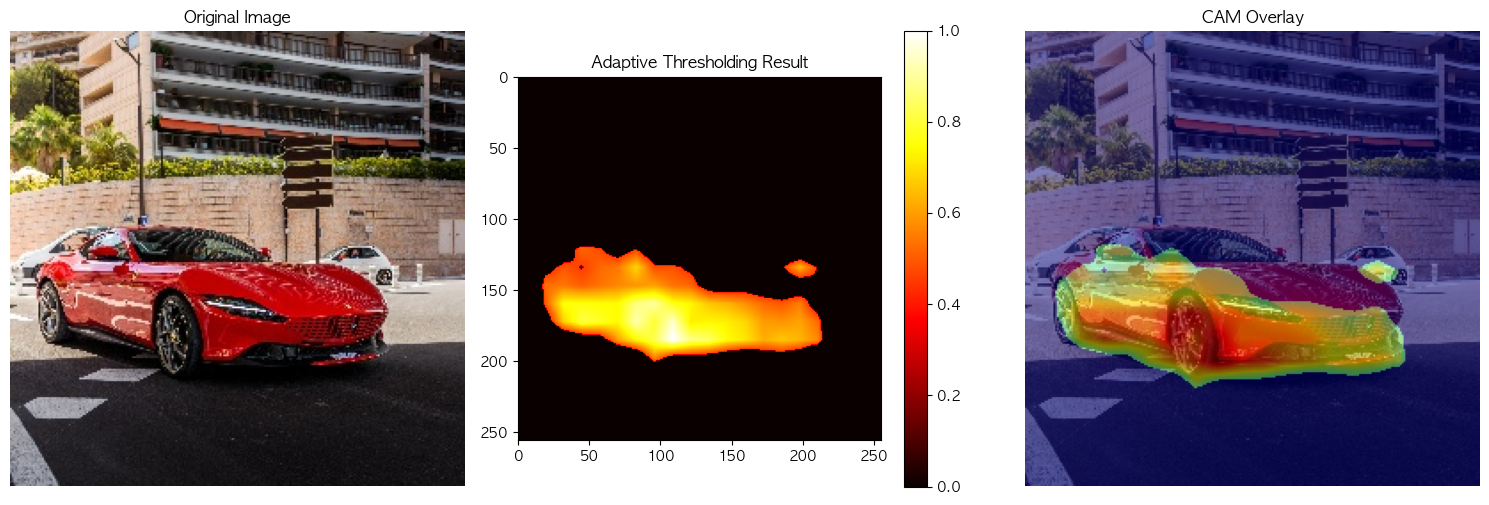

=== Adaptive 쓰레스홀딩 통계 ===
임계값 (85th percentile): 0.459881
활성 픽셀 수: 9,831
활성 픽셀 비율: 15.00%
평균 활성도: 0.6409
최대 활성도: 1.0000


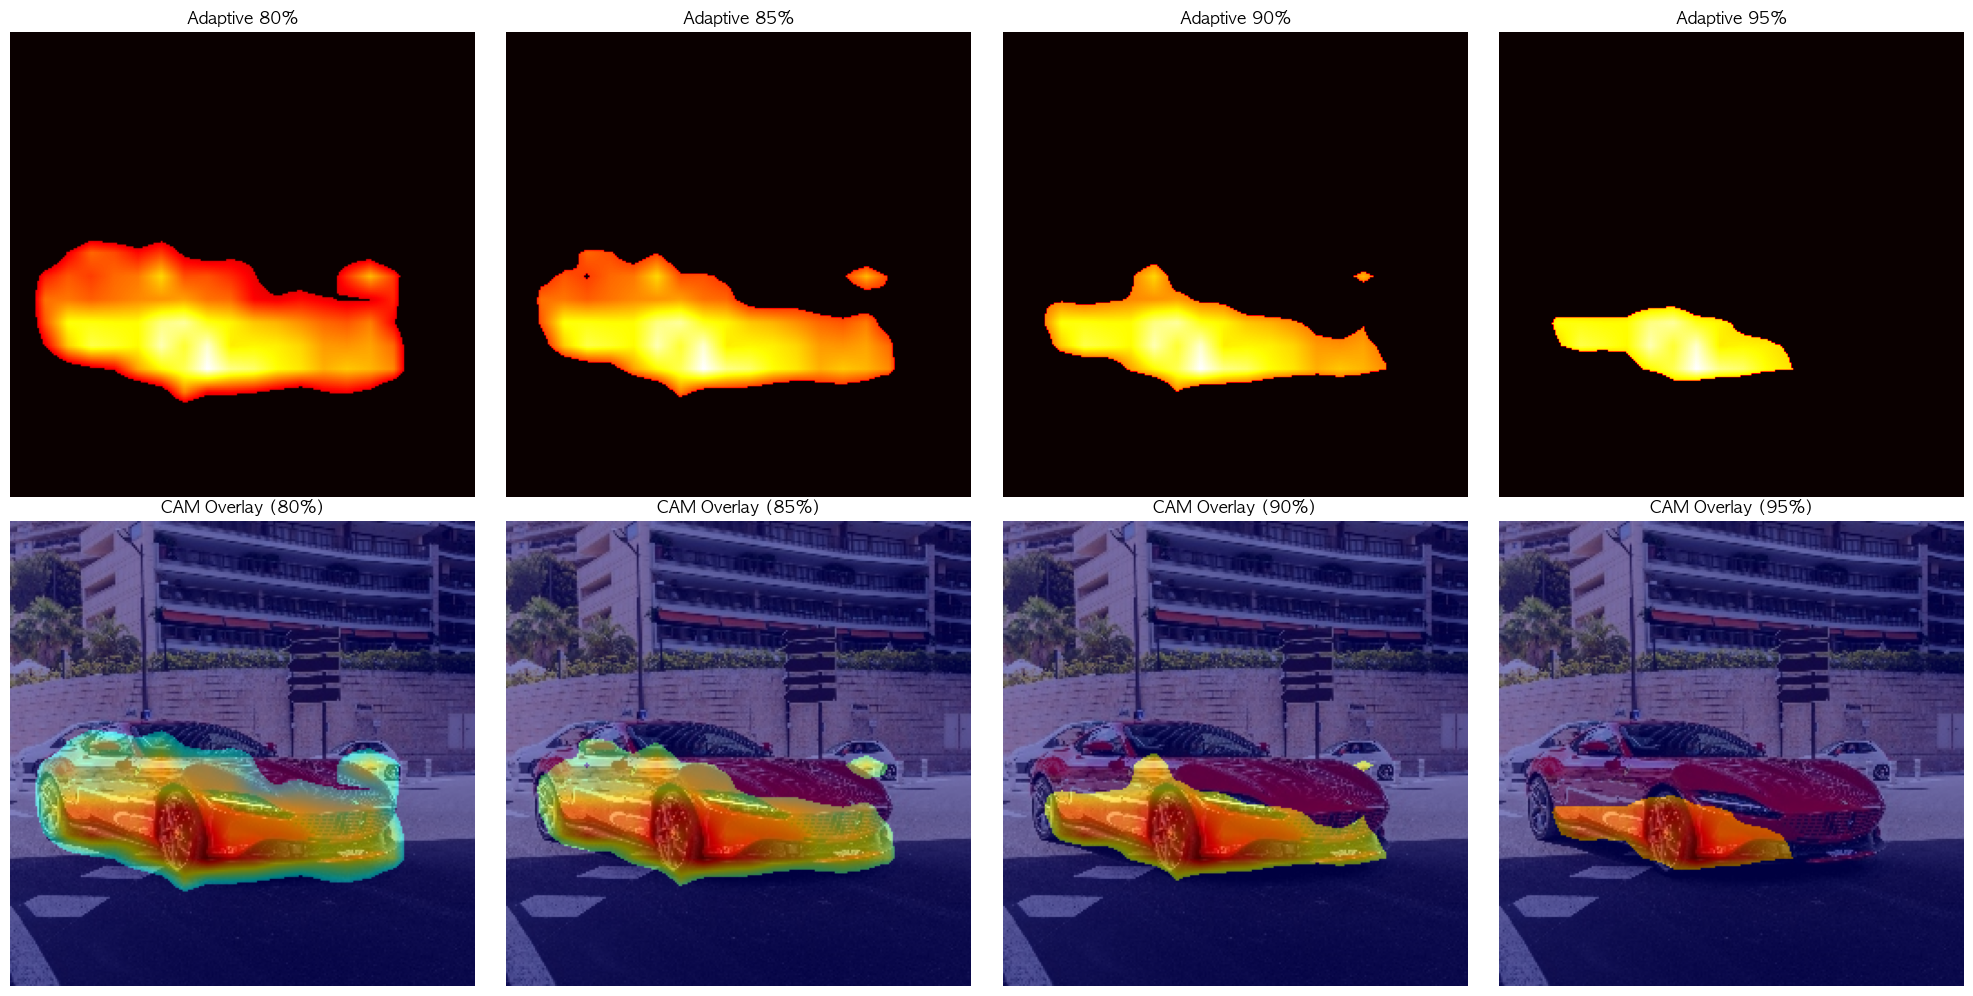

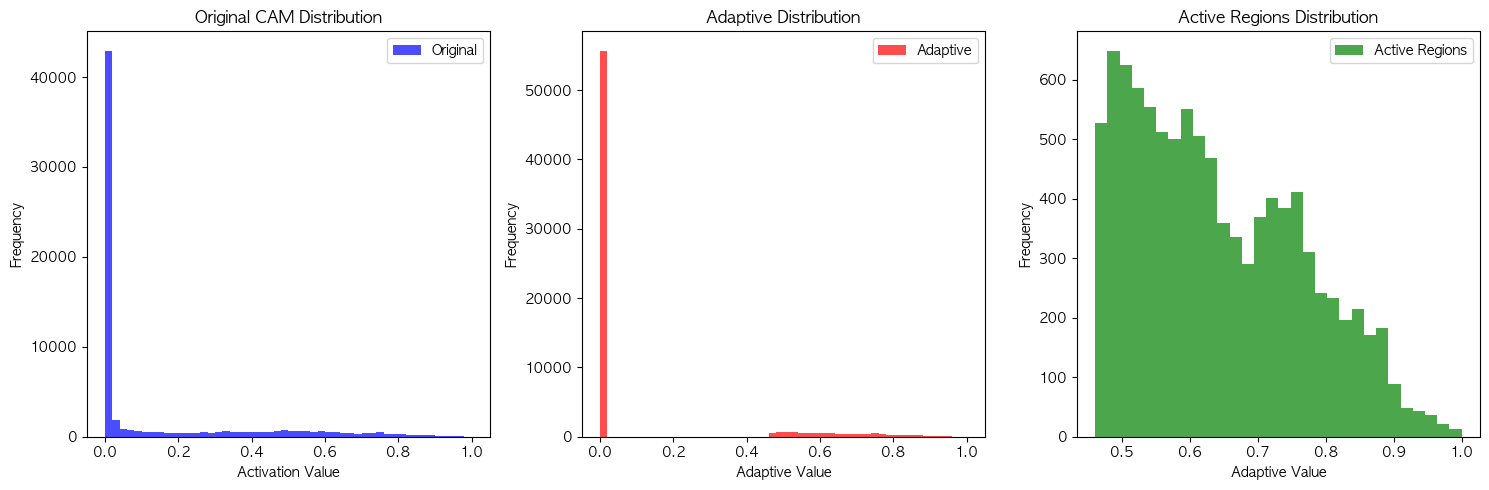

In [12]:
# 활성도가 높은 영역 강조 (상위 10% 픽셀)
threshold = np.percentile(grayscale_cam, 90)
high_activation_mask = grayscale_cam > threshold
# 추가 통계 정보
print(f"\n=== 추가 통계 ===")
print(f"상위 10% 활성도 임계값: {threshold:.6f}")
print(f"상위 10% 활성도 픽셀 수: {np.sum(high_activation_mask):,}")
print(f"상위 10% 활성도 비율: {np.sum(high_activation_mask) / grayscale_cam.size * 100:.2f}%")
# 사분위수 정보
q25, q50, q75 = np.percentile(grayscale_cam, [25, 50, 75])
print(f"1사분위수 (Q1): {q25:.6f}")
print(f"중앙값 (Q2): {q50:.6f}")
print(f"3사분위수 (Q3): {q75:.6f}")
print(f"사분위 범위 (IQR): {q75 - q25:.6f}")

def adaptive_thresholding_visualization(cam, percentile=85):
    """Adaptive 쓰레스홀딩을 사용한 시각화"""
    # Adaptive 쓰레스홀딩 적용
    threshold = np.percentile(cam, percentile)
    cam_filtered = np.where(cam > threshold, cam, 0)
    
    if cam_filtered.max() > 0:
        adaptive_cam = cam_filtered / cam_filtered.max()
    else:
        adaptive_cam = cam_filtered
    
    return adaptive_cam

# Adaptive 쓰레스홀딩 결과
adaptive_result = adaptive_thresholding_visualization(grayscale_cam)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(adaptive_result, cmap='hot')
plt.title('Adaptive Thresholding Result')
plt.colorbar()

plt.subplot(1, 3, 3)
adaptive_cam_image = show_yolocam_on_image(img, adaptive_result, use_rgb=True)
plt.imshow(adaptive_cam_image)
plt.title('CAM Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()


# Adaptive 쓰레스홀딩 통계
print("=== Adaptive 쓰레스홀딩 통계 ===")
print(f"임계값 (85th percentile): {np.percentile(grayscale_cam, 85):.6f}")
print(f"활성 픽셀 수: {np.sum(adaptive_result > 0):,}")
print(f"활성 픽셀 비율: {np.sum(adaptive_result > 0) / adaptive_result.size * 100:.2f}%")
print(f"평균 활성도: {np.mean(adaptive_result[adaptive_result > 0]):.4f}")
print(f"최대 활성도: {np.max(adaptive_result):.4f}")

# 다양한 percentile 값으로 비교
percentiles = [80, 85, 90, 95]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, p in enumerate(percentiles):
    adaptive_result_p = adaptive_thresholding_visualization(grayscale_cam, p)
    
    axes[0, i].imshow(adaptive_result_p, cmap='hot')
    axes[0, i].set_title(f'Adaptive {p}%')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(show_yolocam_on_image(img, adaptive_result_p, use_rgb=True))
    axes[1, i].set_title(f'CAM Overlay ({p}%)')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 분포 비교
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(grayscale_cam.flatten(), bins=50, alpha=0.7, color='blue', label='Original')
plt.title('Original CAM Distribution')
plt.xlabel('Activation Value')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(adaptive_result.flatten(), bins=50, alpha=0.7, color='red', label='Adaptive')
plt.title('Adaptive Distribution')
plt.xlabel('Adaptive Value')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 3, 3)
# 활성 영역만 히스토그램
active_values = adaptive_result[adaptive_result > 0]
if len(active_values) > 0:
    plt.hist(active_values, bins=30, alpha=0.7, color='green', label='Active Regions')
    plt.title('Active Regions Distribution')
    plt.xlabel('Adaptive Value')
    plt.ylabel('Frequency')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'No active regions', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('No Active Regions')

plt.tight_layout()
plt.show()

### clustering

활성도 스레스홀딩 기반 영역 갯수, 크기 측정

In [13]:
from scipy import ndimage
from skimage import measure, morphology
import cv2

In [14]:
def analyze_connected_components(cam, threshold_percentile=85):
    """Connected Components Analysis를 통한 활성화 영역 구조 분석"""
    
    # 임계값 적용
    threshold = np.percentile(cam, threshold_percentile)
    binary_mask = cam > threshold
    
    print(f"=== Connected Components Analysis (임계값: {threshold:.6f}) ===")
    
    # 1. 기본 활성화 영역 통계
    active_pixels = np.sum(binary_mask)
    active_ratio = active_pixels / cam.size * 100
    print(f"1. 기본 활성화 영역:")
    print(f"   - 활성 픽셀 수: {active_pixels:,}")
    print(f"   - 활성 비율: {active_ratio:.2f}%")
    
    # 2. Connected Components 분석
    labeled_mask, num_components = ndimage.label(binary_mask)
    print(f"\n2. Connected Components:")
    print(f"   - 연결된 영역 개수: {num_components}")
    
    if num_components > 0:
        # 각 컴포넌트의 크기 분석
        component_sizes = []
        component_areas = []
        component_centroids = []
        component_bboxes = []
        
        for i in range(1, num_components + 1):
            component_mask = labeled_mask == i
            size = np.sum(component_mask)
            component_sizes.append(size)
            
            # 컴포넌트의 중심점 계산
            y_coords, x_coords = np.where(component_mask)
            centroid_y = np.mean(y_coords)
            centroid_x = np.mean(x_coords)
            component_centroids.append((centroid_x, centroid_y))
            
            # 바운딩 박스 계산
            min_y, max_y = np.min(y_coords), np.max(y_coords)
            min_x, max_x = np.min(x_coords), np.max(x_coords)
            bbox_area = (max_y - min_y + 1) * (max_x - min_x + 1)
            component_areas.append(bbox_area)
            component_bboxes.append((min_x, min_y, max_x, max_y))
        
        # 컴포넌트 크기 통계
        component_sizes = np.array(component_sizes)
        component_areas = np.array(component_areas)
        
        print(f"   - 컴포넌트 크기 통계:")
        print(f"     * 최대 크기: {np.max(component_sizes):,} 픽셀")
        print(f"     * 최소 크기: {np.min(component_sizes):,} 픽셀")
        print(f"     * 평균 크기: {np.mean(component_sizes):.1f} 픽셀")
        print(f"     * 중앙값 크기: {np.median(component_sizes):.1f} 픽셀")
        print(f"     * 표준편차: {np.std(component_sizes):.1f} 픽셀")
        
        # 크기별 컴포넌트 분포
        size_ranges = [(1, 10), (11, 50), (51, 100), (101, 500), (501, 1000), (1001, float('inf'))]
        print(f"   - 크기별 컴포넌트 분포:")
        for min_size, max_size in size_ranges:
            if max_size == float('inf'):
                count = np.sum(component_sizes >= min_size)
            else:
                count = np.sum((component_sizes >= min_size) & (component_sizes < max_size))
            print(f"     * {min_size}-{max_size if max_size != float('inf') else '∞'} 픽셀: {count}개")
        
        # 3. 영역 밀도 분석
        print(f"\n3. 영역 밀도 분석:")
        # 전체 이미지 대비 활성 영역의 밀도
        density = active_pixels / cam.size
        print(f"   - 전체 밀도: {density:.4f}")
        
        # 컴포넌트별 밀도 (바운딩 박스 대비 실제 픽셀 비율)
        component_densities = component_sizes / component_areas
        print(f"   - 평균 컴포넌트 밀도: {np.mean(component_densities):.4f}")
        print(f"   - 최대 컴포넌트 밀도: {np.max(component_densities):.4f}")
        
        # 4. 공간적 분포 분석
        print(f"\n4. 공간적 분포 분석:")
        # 컴포넌트 간 거리 분석
        if num_components > 1:
            distances = []
            for i in range(len(component_centroids)):
                for j in range(i+1, len(component_centroids)):
                    dist = np.sqrt((component_centroids[i][0] - component_centroids[j][0])**2 + 
                                 (component_centroids[i][1] - component_centroids[j][1])**2)
                    distances.append(dist)
            
            distances = np.array(distances)
            print(f"   - 컴포넌트 간 평균 거리: {np.mean(distances):.1f} 픽셀")
            print(f"   - 컴포넌트 간 최소 거리: {np.min(distances):.1f} 픽셀")
            print(f"   - 컴포넌트 간 최대 거리: {np.max(distances):.1f} 픽셀")
        
        # 5. 형태학적 특성
        print(f"\n5. 형태학적 특성:")
        # 컴포넌트의 원형도 (circularity) 계산
        circularities = []
        for i in range(1, num_components + 1):
            component_mask = labeled_mask == i
            # 윤곽선 찾기
            contours, _ = cv2.findContours(component_mask.astype(np.uint8), 
                                         cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                contour = contours[0]
                area = cv2.contourArea(contour)
                perimeter = cv2.arcLength(contour, True)
                if perimeter > 0:
                    circularity = 4 * np.pi * area / (perimeter ** 2)
                    circularities.append(circularity)
        
        if circularities:
            circularities = np.array(circularities)
            print(f"   - 평균 원형도: {np.mean(circularities):.4f}")
            print(f"   - 최대 원형도: {np.max(circularities):.4f}")
            print(f"   - 최소 원형도: {np.min(circularities):.4f}")
        
        return {
            'num_components': num_components,
            'component_sizes': component_sizes,
            'component_centroids': component_centroids,
            'component_bboxes': component_bboxes,
            'component_densities': component_densities,
            'circularities': circularities if len(circularities) > 0 else [],
            'labeled_mask': labeled_mask,
            'binary_mask': binary_mask
        }
    
    return None

In [15]:
# 다양한 임계값으로 분석
percentiles = [80, 85, 90, 95]
threshold_results = {}

for p in percentiles:
    print(f"\n{'='*60}")
    threshold_results[p] = analyze_connected_components(grayscale_cam, p)


=== Connected Components Analysis (임계값: 0.331514) ===
1. 기본 활성화 영역:
   - 활성 픽셀 수: 13,107
   - 활성 비율: 20.00%

2. Connected Components:
   - 연결된 영역 개수: 1
   - 컴포넌트 크기 통계:
     * 최대 크기: 13,107 픽셀
     * 최소 크기: 13,107 픽셀
     * 평균 크기: 13107.0 픽셀
     * 중앙값 크기: 13107.0 픽셀
     * 표준편차: 0.0 픽셀
   - 크기별 컴포넌트 분포:
     * 1-10 픽셀: 0개
     * 11-50 픽셀: 0개
     * 51-100 픽셀: 0개
     * 101-500 픽셀: 0개
     * 501-1000 픽셀: 0개
     * 1001-∞ 픽셀: 1개

3. 영역 밀도 분석:
   - 전체 밀도: 0.2000
   - 평균 컴포넌트 밀도: 0.7255
   - 최대 컴포넌트 밀도: 0.7255

4. 공간적 분포 분석:

5. 형태학적 특성:
   - 평균 원형도: 0.4472
   - 최대 원형도: 0.4472
   - 최소 원형도: 0.4472

=== Connected Components Analysis (임계값: 0.459881) ===
1. 기본 활성화 영역:
   - 활성 픽셀 수: 9,831
   - 활성 비율: 15.00%

2. Connected Components:
   - 연결된 영역 개수: 2
   - 컴포넌트 크기 통계:
     * 최대 크기: 9,638 픽셀
     * 최소 크기: 193 픽셀
     * 평균 크기: 4915.5 픽셀
     * 중앙값 크기: 4915.5 픽셀
     * 표준편차: 4722.5 픽셀
   - 크기별 컴포넌트 분포:
     * 1-10 픽셀: 0개
     * 11-50 픽셀: 0개
     * 51-100 픽셀: 0개
     * 101-500 픽셀: 1개
     * 501-10

활성 영역 개수가 최대인 임계값: 85% (영역 개수: 2개)


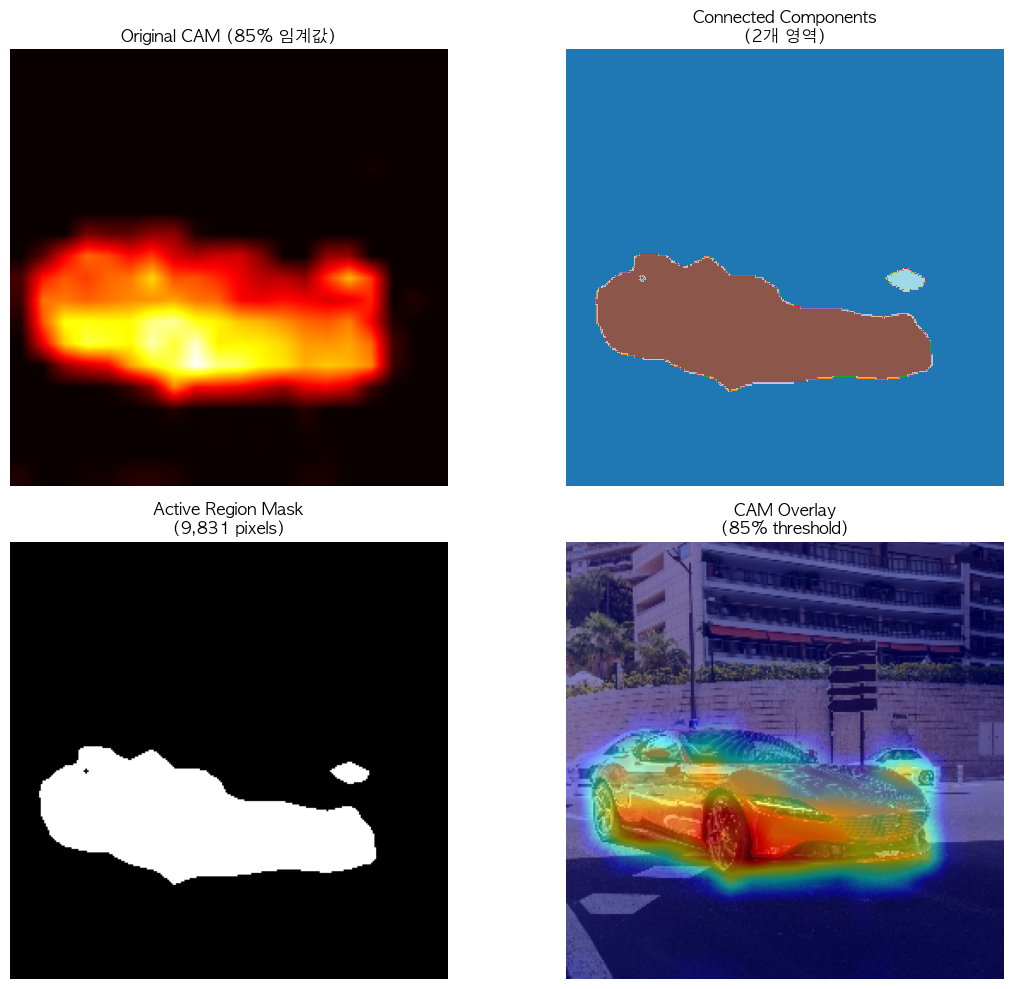


=== 최대 활성 영역 분석 결과 (85% 임계값) ===
활성 영역 개수: 2개
활성 픽셀 수: 9,831
활성 비율: 15.00%
평균 컴포넌트 크기: 4915.5 픽셀
최대 컴포넌트 크기: 9,638 픽셀
최소 컴포넌트 크기: 193 픽셀

크기별 컴포넌트 분포:
  1-10 픽셀: 0개
  11-50 픽셀: 0개
  51-100 픽셀: 0개
  101-500 픽셀: 1개
  501-1000 픽셀: 0개
  1001-∞ 픽셀: 1개


In [16]:
# 활성 영역 개수가 최대인 임계값 찾기
max_components = 0
best_percentile = None

for p in percentiles:
    if threshold_results[p] and threshold_results[p]['num_components'] > max_components:
        max_components = threshold_results[p]['num_components']
        best_percentile = p

if best_percentile is not None:
    print(f"활성 영역 개수가 최대인 임계값: {best_percentile}% (영역 개수: {max_components}개)")
    
    # 최대 활성 영역을 가진 결과만 시각화
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. 원본 CAM
    axes[0, 0].imshow(grayscale_cam, cmap='hot')
    axes[0, 0].set_title(f'Original CAM ({best_percentile}% 임계값)')
    axes[0, 0].axis('off')
    
    # 2. Connected Components
    labeled_mask = threshold_results[best_percentile]['labeled_mask']
    axes[0, 1].imshow(labeled_mask, cmap='tab20')
    axes[0, 1].set_title(f'Connected Components\n({threshold_results[best_percentile]["num_components"]}개 영역)')
    axes[0, 1].axis('off')
    
    # 3. 활성 영역 마스크
    axes[1, 0].imshow(threshold_results[best_percentile]['binary_mask'], cmap='gray')
    active_pixels = np.sum(threshold_results[best_percentile]['binary_mask'])
    axes[1, 0].set_title(f'Active Region Mask\n({active_pixels:,} pixels)')
    axes[1, 0].axis('off')
    
    # 4. CAM Overlay with Active Regions
    cam_overlay = show_yolocam_on_image(img, grayscale_cam, use_rgb=True)
    axes[1, 1].imshow(cam_overlay)
    axes[1, 1].set_title(f'CAM Overlay\n({best_percentile}% threshold)')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 상세 정보 출력
    print(f"\n=== 최대 활성 영역 분석 결과 ({best_percentile}% 임계값) ===")
    result = threshold_results[best_percentile]
    print(f"활성 영역 개수: {result['num_components']}개")
    print(f"활성 픽셀 수: {active_pixels:,}")
    active_ratio = active_pixels / grayscale_cam.size * 100
    print(f"활성 비율: {active_ratio:.2f}%")
    
    if result['num_components'] > 0:
        print(f"평균 컴포넌트 크기: {np.mean(result['component_sizes']):.1f} 픽셀")
        print(f"최대 컴포넌트 크기: {np.max(result['component_sizes']):,} 픽셀")
        print(f"최소 컴포넌트 크기: {np.min(result['component_sizes']):,} 픽셀")
        
        # 크기별 분포 출력
        print(f"\n크기별 컴포넌트 분포:")
        size_ranges = [(1, 10), (11, 50), (51, 100), (101, 500), (501, 1000), (1001, float('inf'))]
        for min_size, max_size in size_ranges:
            if max_size == float('inf'):
                count = np.sum(result['component_sizes'] >= min_size)
            else:
                count = np.sum((result['component_sizes'] >= min_size) & (result['component_sizes'] < max_size))
            print(f"  {min_size}-{max_size if max_size != float('inf') else '∞'} 픽셀: {count}개")

else:
    print("유효한 임계값 결과가 없습니다.")

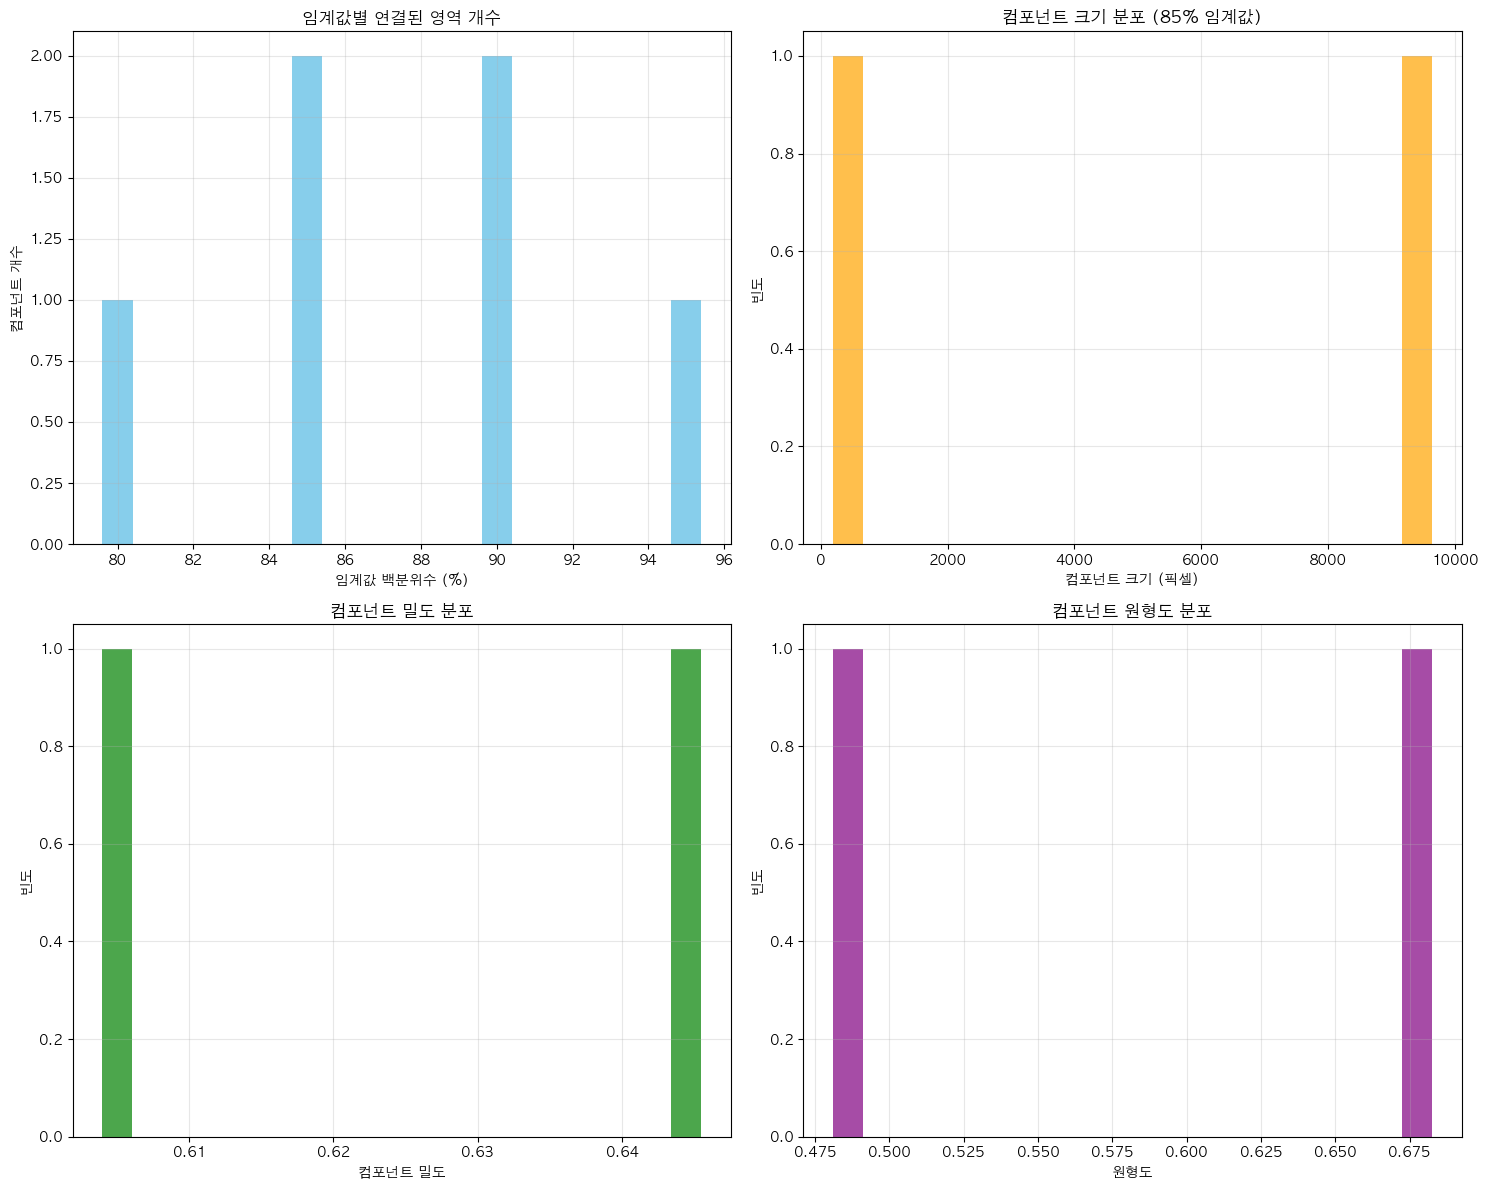

In [17]:
# 컴포넌트 크기 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 임계값별 컴포넌트 개수
component_counts = [threshold_results[p]['num_components'] if threshold_results[p] else 0 for p in percentiles]
axes[0, 0].bar(percentiles, component_counts, color='skyblue')
axes[0, 0].set_xlabel('임계값 백분위수 (%)')
axes[0, 0].set_ylabel('컴포넌트 개수')
axes[0, 0].set_title('임계값별 연결된 영역 개수')
axes[0, 0].grid(True, alpha=0.3)

# 2. 컴포넌트 크기 분포 (85% 임계값 기준)
if threshold_results[85]:
    sizes = threshold_results[85]['component_sizes']
    axes[0, 1].hist(sizes, bins=20, alpha=0.7, color='orange')
    axes[0, 1].set_xlabel('컴포넌트 크기 (픽셀)')
    axes[0, 1].set_ylabel('빈도')
    axes[0, 1].set_title('컴포넌트 크기 분포 (85% 임계값)')
    axes[0, 1].grid(True, alpha=0.3)

# 3. 컴포넌트 밀도 분포
if threshold_results[85]:
    densities = threshold_results[85]['component_densities']
    axes[1, 0].hist(densities, bins=20, alpha=0.7, color='green')
    axes[1, 0].set_xlabel('컴포넌트 밀도')
    axes[1, 0].set_ylabel('빈도')
    axes[1, 0].set_title('컴포넌트 밀도 분포')
    axes[1, 0].grid(True, alpha=0.3)

# 4. 원형도 분포
if threshold_results[85] and len(threshold_results[85]['circularities']) > 0:
    circularities = threshold_results[85]['circularities']
    axes[1, 1].hist(circularities, bins=20, alpha=0.7, color='purple')
    axes[1, 1].set_xlabel('원형도')
    axes[1, 1].set_ylabel('빈도')
    axes[1, 1].set_title('컴포넌트 원형도 분포')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# 상세한 컴포넌트 정보 출력
def print_detailed_component_info(results, percentile=85):
    """특정 임계값의 상세한 컴포넌트 정보 출력"""
    if not results[percentile]:
        return
    
    result = results[percentile]
    print(f"\n=== 상세 컴포넌트 정보 ({percentile}% 임계값) ===")
    
    # 크기 순으로 정렬
    sorted_indices = np.argsort(result['component_sizes'])[::-1]
    
    print(f"총 {result['num_components']}개 컴포넌트 (크기 순 정렬):")
    print(f"{'순위':<4} {'크기':<8} {'밀도':<8} {'원형도':<8} {'중심점':<15}")
    print("-" * 50)
    
    for i, idx in enumerate(sorted_indices[:10]):  # 상위 10개만 출력
        size = result['component_sizes'][idx]
        density = result['component_densities'][idx]
        centroid = result['component_centroids'][idx]
        
        if i < len(result['circularities']):
            circularity = result['circularities'][idx]
        else:
            circularity = 0
        
        print(f"{i+1:<4} {size:<8,} {density:<8.4f} {circularity:<8.4f} ({centroid[0]:.1f}, {centroid[1]:.1f})")

print_detailed_component_info(threshold_results, 85)


=== 상세 컴포넌트 정보 (85% 임계값) ===
총 2개 컴포넌트 (크기 순 정렬):
순위   크기       밀도       원형도      중심점            
--------------------------------------------------
1    9,638    0.6040   0.4811   (106.2, 163.4)
2    193      0.6455   0.6825   (198.5, 135.2)


### centroid

가중치 중심 좌표

In [19]:
def calculate_cam_centroids(cam, method='weighted'):
    """CAM의 centroid 좌표를 다양한 방법으로 계산"""
    
    print("=== CAM Centroid 계산 ===")
    
    # 1. 활성도 가중 평균 centroid (가장 일반적)
    if method == 'weighted':
        # 활성도가 높은 픽셀에 더 큰 가중치를 부여
        y_coords, x_coords = np.meshgrid(np.arange(cam.shape[0]), np.arange(cam.shape[1]), indexing='ij')
        
        # 활성도로 가중치 계산
        total_weight = np.sum(cam)
        if total_weight > 0:
            weighted_x = np.sum(x_coords * cam) / total_weight
            weighted_y = np.sum(y_coords * cam) / total_weight
        else:
            weighted_x, weighted_y = cam.shape[1] / 2, cam.shape[0] / 2
        
        print(f"1. 활성도 가중 평균 centroid:")
        print(f"   - X 좌표: {weighted_x:.2f}")
        print(f"   - Y 좌표: {weighted_y:.2f}")
        print(f"   - 의미: 활성도가 높은 영역에 더 큰 가중치를 부여한 중심점")
        
        return weighted_x, weighted_y
    
    # 2. 임계값 기반 centroid
    elif method == 'threshold':
        # 임계값 이상인 픽셀들의 평균 위치
        threshold = np.percentile(cam, 85)  # 상위 15%
        active_mask = cam > threshold
        
        if np.sum(active_mask) > 0:
            y_coords, x_coords = np.where(active_mask)
            threshold_x = np.mean(x_coords)
            threshold_y = np.mean(y_coords)
        else:
            threshold_x, threshold_y = cam.shape[1] / 2, cam.shape[0] / 2
        
        print(f"2. 임계값 기반 centroid (임계값: {threshold:.6f}):")
        print(f"   - X 좌표: {threshold_x:.2f}")
        print(f"   - Y 좌표: {threshold_y:.2f}")
        print(f"   - 활성 픽셀 수: {np.sum(active_mask):,}")
        
        return threshold_x, threshold_y
    
    # 3. 최대 활성도 위치
    elif method == 'max':
        max_idx = np.unravel_index(np.argmax(cam), cam.shape)
        max_y, max_x = max_idx
        
        print(f"3. 최대 활성도 위치:")
        print(f"   - X 좌표: {max_x:.2f}")
        print(f"   - Y 좌표: {max_y:.2f}")
        print(f"   - 최대 활성도: {cam[max_y, max_x]:.6f}")
        
        return max_x, max_y
    
    # 4. Connected Components 기반 centroid
    elif method == 'components':
        threshold = np.percentile(cam, 85)
        binary_mask = cam > threshold
        labeled_mask, num_components = ndimage.label(binary_mask)
        
        if num_components > 0:
            # 가장 큰 컴포넌트의 centroid
            component_sizes = []
            component_centroids = []
            
            for i in range(1, num_components + 1):
                component_mask = labeled_mask == i
                size = np.sum(component_mask)
                component_sizes.append(size)
                
                y_coords, x_coords = np.where(component_mask)
                centroid_y = np.mean(y_coords)
                centroid_x = np.mean(x_coords)
                component_centroids.append((centroid_x, centroid_y))
            
            # 가장 큰 컴포넌트 선택
            largest_idx = np.argmax(component_sizes)
            largest_x, largest_y = component_centroids[largest_idx]
            
            print(f"4. 최대 컴포넌트 centroid:")
            print(f"   - X 좌표: {largest_x:.2f}")
            print(f"   - Y 좌표: {largest_y:.2f}")
            print(f"   - 컴포넌트 크기: {component_sizes[largest_idx]:,} 픽셀")
            print(f"   - 총 컴포넌트 수: {num_components}")
            
            return largest_x, largest_y
        else:
            print("4. 활성 컴포넌트가 없습니다.")
            return cam.shape[1] / 2, cam.shape[0] / 2

In [20]:
# 다양한 방법으로 centroid 계산
methods = ['weighted', 'threshold', 'max', 'components']
centroids = {}

for method in methods:
    print(f"\n{'='*50}")
    centroids[method] = calculate_cam_centroids(grayscale_cam, method)


=== CAM Centroid 계산 ===
1. 활성도 가중 평균 centroid:
   - X 좌표: 112.41
   - Y 좌표: 160.83
   - 의미: 활성도가 높은 영역에 더 큰 가중치를 부여한 중심점

=== CAM Centroid 계산 ===
2. 임계값 기반 centroid (임계값: 0.459881):
   - X 좌표: 108.02
   - Y 좌표: 162.89
   - 활성 픽셀 수: 9,831

=== CAM Centroid 계산 ===
3. 최대 활성도 위치:
   - X 좌표: 108.00
   - Y 좌표: 185.00
   - 최대 활성도: 1.000000

=== CAM Centroid 계산 ===
4. 최대 컴포넌트 centroid:
   - X 좌표: 106.21
   - Y 좌표: 163.45
   - 컴포넌트 크기: 9,638 픽셀
   - 총 컴포넌트 수: 2


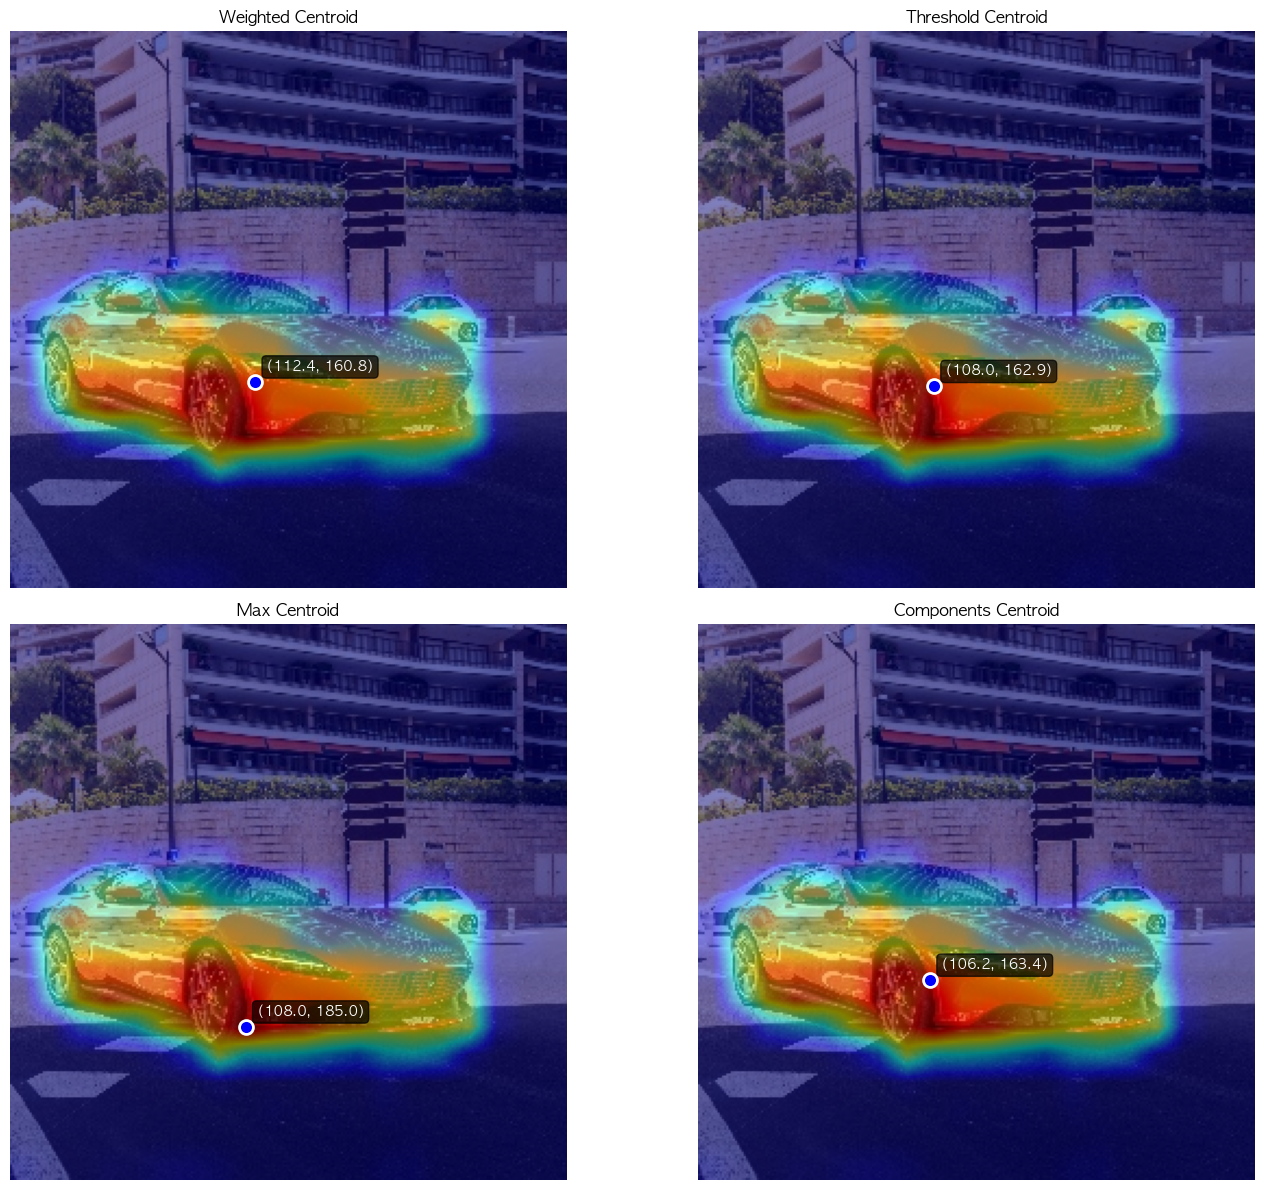

In [21]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i, method in enumerate(methods):
    row = i // 2
    col = i % 2
    
    # CAM 히트맵
    im = axes[row, col].imshow(cam_image)
    axes[row, col].set_title(f'{method.capitalize()} Centroid')
    
    # Centroid 표시
    if centroids[method]:
        x, y = centroids[method]
        axes[row, col].plot(x, y, 'bo', markersize=10, markeredgecolor='white', markeredgewidth=2)
        axes[row, col].text(x + 5, y - 5, f'({x:.1f}, {y:.1f})', 
                           color='white', fontsize=10, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Centroid 비교 테이블
print("\n=== Centroid 좌표 비교 ===")
print(f"{'방법':<15} {'X 좌표':<10} {'Y 좌표':<10} {'설명':<30}")
print("-" * 70)

for method in methods:
    if centroids[method]:
        x, y = centroids[method]
        if method == 'weighted':
            desc = "활성도 가중 평균"
        elif method == 'threshold':
            desc = "임계값 이상 픽셀 평균"
        elif method == 'max':
            desc = "최대 활성도 위치"
        elif method == 'components':
            desc = "최대 컴포넌트 중심"
        
        print(f"{method:<15} {x:<10.2f} {y:<10.2f} {desc:<30}")

# Centroid 간 거리 계산
print(f"\n=== Centroid 간 거리 ===")
for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods[i+1:], i+1):
        if centroids[method1] and centroids[method2]:
            x1, y1 = centroids[method1]
            x2, y2 = centroids[method2]
            distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            print(f"{method1} ↔ {method2}: {distance:.2f} 픽셀")

# 이미지 중심과의 거리
image_center_x = grayscale_cam.shape[1] / 2
image_center_y = grayscale_cam.shape[0] / 2

print(f"\n=== 이미지 중심과의 거리 ===")
print(f"이미지 중심: ({image_center_x:.1f}, {image_center_y:.1f})")
for method in methods:
    if centroids[method]:
        x, y = centroids[method]
        distance = np.sqrt((x - image_center_x)**2 + (y - image_center_y)**2)
        print(f"{method}: {distance:.2f} 픽셀")


=== Centroid 좌표 비교 ===
방법              X 좌표       Y 좌표       설명                            
----------------------------------------------------------------------
weighted        112.41     160.83     활성도 가중 평균                     
threshold       108.02     162.89     임계값 이상 픽셀 평균                  
max             108.00     185.00     최대 활성도 위치                     
components      106.21     163.45     최대 컴포넌트 중심                    

=== Centroid 간 거리 ===
weighted ↔ threshold: 4.85 픽셀
weighted ↔ max: 24.57 픽셀
weighted ↔ components: 6.73 픽셀
threshold ↔ max: 22.11 픽셀
threshold ↔ components: 1.90 픽셀
max ↔ components: 21.63 픽셀

=== 이미지 중심과의 거리 ===
이미지 중심: (128.0, 128.0)
weighted: 36.34 픽셀
threshold: 40.21 픽셀
max: 60.41 픽셀
components: 41.61 픽셀


In [23]:
# 가장 신뢰할 만한 centroid 선택
def select_best_centroid(centroids, cam):
    """CAM 특성에 따른 최적 centroid 선택"""
    print(f"\n=== 최적 Centroid 선택 ===")
    
    # 활성 영역의 특성 분석
    active_ratio = np.sum(cam > 0) / cam.size
    max_val = np.max(cam)
    mean_val = np.mean(cam)
    
    print(f"활성 영역 비율: {active_ratio:.2%}")
    print(f"최대 활성도: {max_val:.6f}")
    print(f"평균 활성도: {mean_val:.6f}")
    
    if active_ratio < 0.05:  # 활성 영역이 매우 작음
        print("추천: 'max' 방법 (활성 영역이 매우 작아 최대값 위치가 의미있음)")
        return 'max'
    elif active_ratio < 0.15:  # 활성 영역이 작음
        print("추천: 'components' 방법 (연결된 영역의 중심이 의미있음)")
        return 'components'
    else:  # 활성 영역이 넓음
        print("추천: 'weighted' 방법 (전체 활성도 분포를 고려한 중심)")
        return 'weighted'

In [24]:
best_method = select_best_centroid(centroids, grayscale_cam)
best_centroid = centroids[best_method]

print(f"\n선택된 최적 centroid: {best_method}")
print(f"좌표: ({best_centroid[0]:.2f}, {best_centroid[1]:.2f})")


=== 최적 Centroid 선택 ===
활성 영역 비율: 47.48%
최대 활성도: 1.000000
평균 활성도: 0.137783
추천: 'weighted' 방법 (전체 활성도 분포를 고려한 중심)

선택된 최적 centroid: weighted
좌표: (112.41, 160.83)


### overlap

CAM 영역과 GT Bbox 영역의 겹침 정도 수치화 (precision / recall 계산)

In [25]:
def calculate_cam_bbox_overlap(cam, boxes, names, threshold_percentile=85):
    """CAM 활성 영역과 가장 큰 bbox 간의 overlap 계산"""
    
    # parse_detections 함수 결과에서 가장 큰 bbox 찾기
    if len(boxes) == 0:
        print("감지된 객체가 없습니다.")
        return None
    
    # bbox 면적 계산하여 가장 큰 것 선택
    areas = []
    for box in boxes:
        x1, y1, x2, y2 = box
        area = (x2 - x1) * (y2 - y1)
        areas.append(area)
    
    largest_idx = np.argmax(areas)
    largest_bbox = boxes[largest_idx]
    largest_area = areas[largest_idx]
    largest_name = names[largest_idx]
    
    print(f"=== 가장 큰 Bbox 정보 ===")
    print(f"Bbox 좌표: {largest_bbox}")
    print(f"클래스: {largest_name}")
    print(f"면적: {largest_area:.2f} 픽셀²")
    
    # bbox 정보 추출
    x1, y1, x2, y2 = largest_bbox
    
    # bbox를 이미지 경계 내로 제한
    img_height, img_width = cam.shape
    x1 = max(0, min(int(x1), img_width-1))
    y1 = max(0, min(int(y1), img_height-1))
    x2 = max(0, min(int(x2), img_width-1))
    y2 = max(0, min(int(y2), img_height-1))
    
    # bbox 마스크 생성
    bbox_mask = np.zeros_like(cam, dtype=bool)
    bbox_mask[y1:y2+1, x1:x2+1] = True
    
    # CAM 활성 영역 마스크 생성
    threshold = np.percentile(cam, threshold_percentile)
    cam_active_mask = cam > threshold
    
    # Overlap 계산
    intersection = np.logical_and(bbox_mask, cam_active_mask)
    union = np.logical_or(bbox_mask, cam_active_mask)
    
    # IoU (Intersection over Union)
    intersection_area = np.sum(intersection)
    union_area = np.sum(union)
    iou = intersection_area / union_area if union_area > 0 else 0
    
    # 추가 overlap 메트릭들
    bbox_area = np.sum(bbox_mask)
    cam_active_area = np.sum(cam_active_mask)
    
    # CAM이 bbox를 얼마나 덮는지 (CAM coverage of bbox)
    cam_coverage = intersection_area / bbox_area if bbox_area > 0 else 0
    
    # bbox가 CAM을 얼마나 덮는지 (bbox coverage of CAM)
    bbox_coverage = intersection_area / cam_active_area if cam_active_area > 0 else 0
    
    return {
        'iou': iou,
        'cam_coverage': cam_coverage,
        'bbox_coverage': bbox_coverage,
        'intersection_area': intersection_area,
        'bbox_area': bbox_area,
        'cam_active_area': cam_active_area,
        'union_area': union_area,
        'bbox_coords': (x1, y1, x2, y2),
        'bbox_mask': bbox_mask,
        'cam_active_mask': cam_active_mask,
        'intersection_mask': intersection,
        'largest_bbox_idx': largest_idx,
        'all_areas': areas,
        'largest_class_name': largest_name,
        'all_class_names': names,
    }

In [26]:
# Overlap 계산
overlap_results = calculate_cam_bbox_overlap(grayscale_cam, boxes, names)

print(f"\n=== CAM-Bbox Overlap 분석 ===")
print(f"대상 객체: {overlap_results['largest_class_name']}")
print(f"IoU (Intersection over Union): {overlap_results['iou']:.4f}")
print(f"CAM이 bbox를 덮는 비율: {overlap_results['cam_coverage']:.4f}")
print(f"Bbox가 CAM을 덮는 비율: {overlap_results['bbox_coverage']:.4f}")
print(f"교집합 면적: {overlap_results['intersection_area']:,} 픽셀")
print(f"Bbox 면적: {overlap_results['bbox_area']:,} 픽셀")
print(f"CAM 활성 면적: {overlap_results['cam_active_area']:,} 픽셀")
print(f"합집합 면적: {overlap_results['union_area']:,} 픽셀")

=== 가장 큰 Bbox 정보 ===
Bbox 좌표: [     11.898      108.44      211.66      194.58]
클래스: car 0.53
면적: 17208.06 픽셀²

=== CAM-Bbox Overlap 분석 ===
대상 객체: car 0.53
IoU (Intersection over Union): 0.5519
CAM이 bbox를 덮는 비율: 0.5556
Bbox가 CAM을 덮는 비율: 0.9882
교집합 면적: 9,715 픽셀
Bbox 면적: 17,487 픽셀
CAM 활성 면적: 9,831 픽셀
합집합 면적: 17,603 픽셀


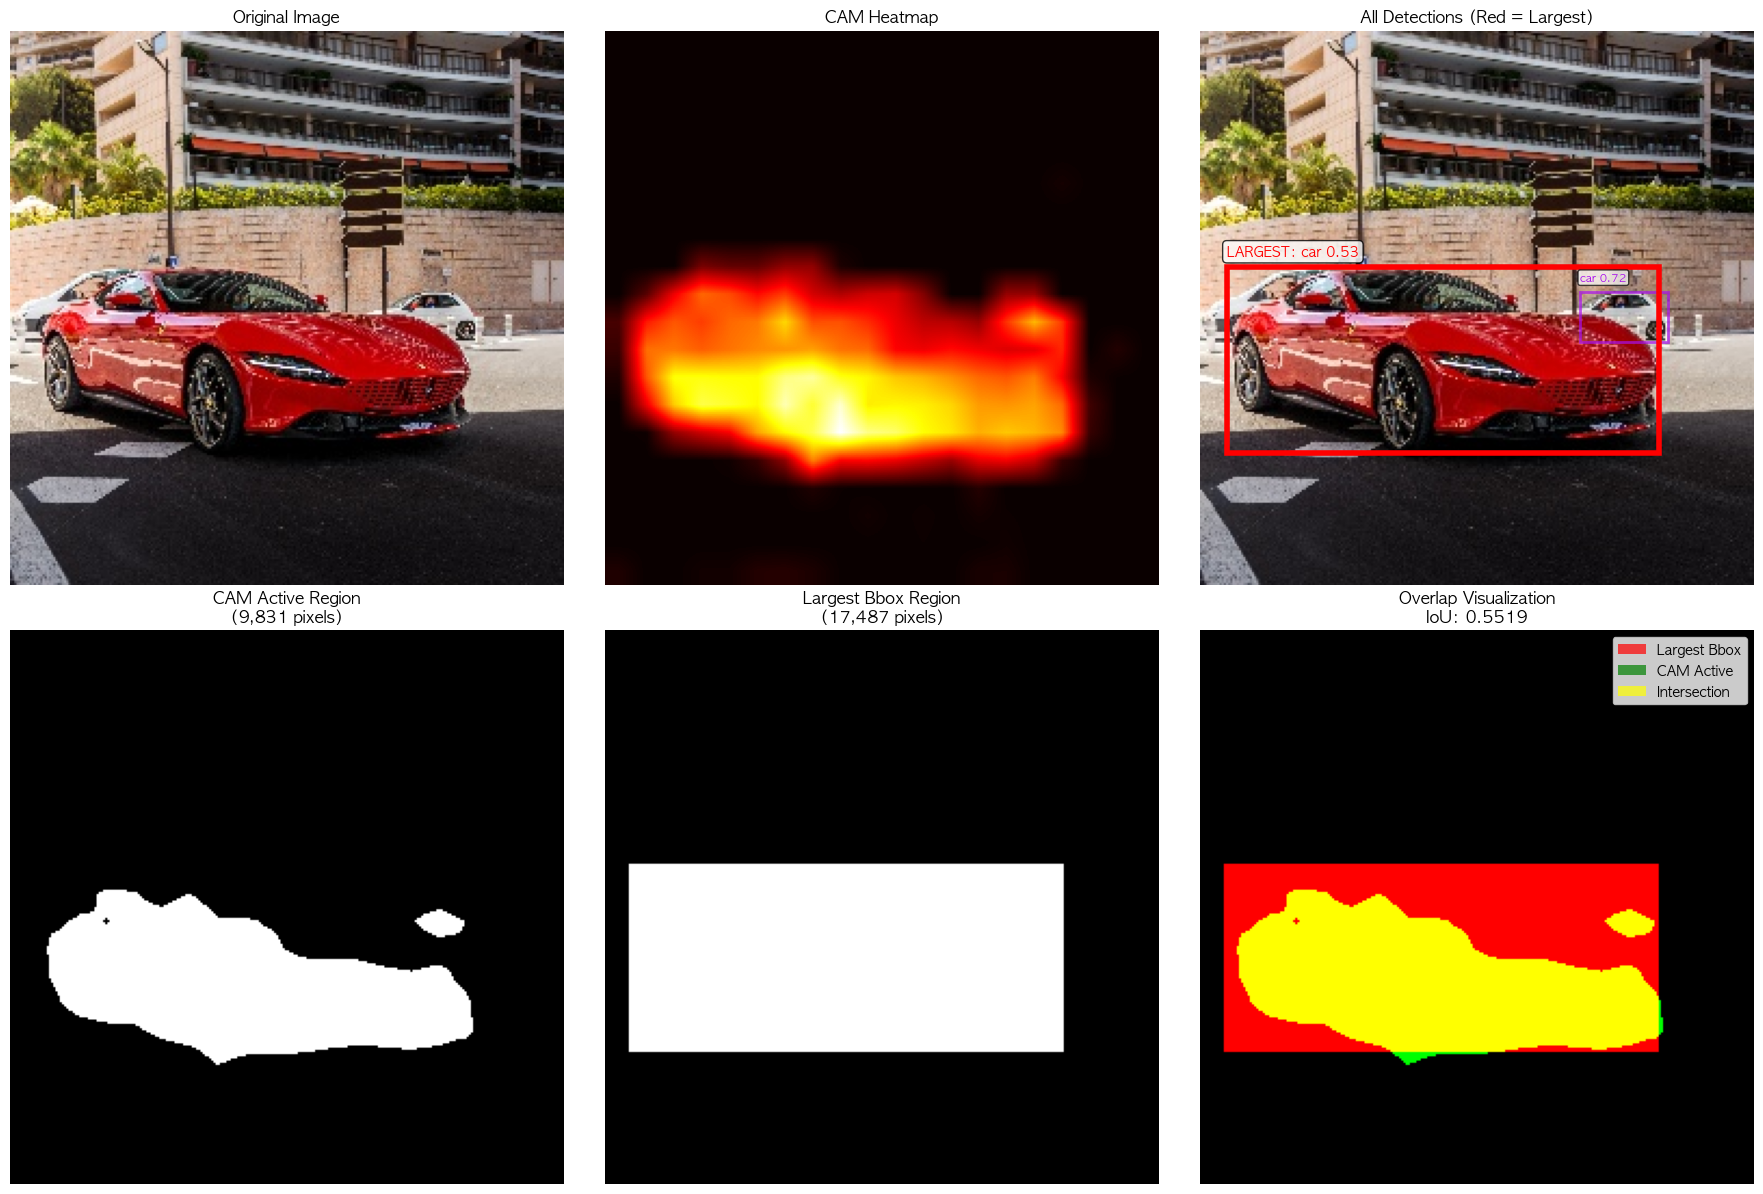

In [27]:
# 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 원본 이미지
axes[0, 0].imshow(rgb_img)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# 2. CAM 히트맵
axes[0, 1].imshow(grayscale_cam, cmap='hot')
axes[0, 1].set_title('CAM Heatmap')
axes[0, 1].axis('off')

# 3. 모든 bbox와 가장 큰 bbox 표시
axes[0, 2].imshow(rgb_img)
# 모든 bbox 표시 (연한 색상)
for i, (box, color, name) in enumerate(zip(boxes, colors, names)):
    x1, y1, x2, y2 = box
    # matplotlib용 색상 정규화 (0-255 → 0-1)
    if np.max(color) > 1:
        normalized_color = np.array(color) / 255.0
    else:
        normalized_color = color
    
    if i == overlap_results['largest_bbox_idx']:
        # 가장 큰 bbox는 굵은 선으로 표시
        axes[0, 2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                         fill=False, edgecolor='red', linewidth=4))
        axes[0, 2].text(x1, y1-5, f'LARGEST: {name}', 
                       color='red', fontsize=10, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    else:
        # 다른 bbox는 얇은 선으로 표시
        axes[0, 2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                         fill=False, edgecolor=normalized_color, linewidth=2, alpha=0.7))
        axes[0, 2].text(x1, y1-5, name, color=normalized_color, fontsize=8,
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

axes[0, 2].set_title('All Detections (Red = Largest)')
axes[0, 2].axis('off')

# 4. CAM 활성 영역
axes[1, 0].imshow(overlap_results['cam_active_mask'], cmap='gray')
axes[1, 0].set_title(f'CAM Active Region\n({overlap_results["cam_active_area"]:,} pixels)')
axes[1, 0].axis('off')

# 5. 가장 큰 bbox 마스크
axes[1, 1].imshow(overlap_results['bbox_mask'], cmap='gray')
axes[1, 1].set_title(f'Largest Bbox Region\n({overlap_results["bbox_area"]:,} pixels)')
axes[1, 1].axis('off')

# 6. Overlap 시각화
overlap_vis = np.zeros((*grayscale_cam.shape, 3))
overlap_vis[overlap_results['bbox_mask']] = [1, 0, 0]  # 빨간색: bbox
overlap_vis[overlap_results['cam_active_mask']] = [0, 1, 0]  # 초록색: CAM
overlap_vis[overlap_results['intersection_mask']] = [1, 1, 0]  # 노란색: 교집합

axes[1, 2].imshow(overlap_vis)
axes[1, 2].set_title(f'Overlap Visualization\nIoU: {overlap_results["iou"]:.4f}')
axes[1, 2].axis('off')

# 범례 추가
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='red', alpha=0.7, label='Largest Bbox'),
    plt.Rectangle((0, 0), 1, 1, facecolor='green', alpha=0.7, label='CAM Active'),
    plt.Rectangle((0, 0), 1, 1, facecolor='yellow', alpha=0.7, label='Intersection')
]
axes[1, 2].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [28]:
# Overlap 해석
print(f"\n=== Overlap 해석 ===")
iou = overlap_results['iou']
cam_coverage = overlap_results['cam_coverage']
bbox_coverage = overlap_results['bbox_coverage']
class_name = overlap_results['largest_class_name']

if iou > 0.7:
    overlap_quality = "매우 좋음"
elif iou > 0.5:
    overlap_quality = "좋음"
elif iou > 0.3:
    overlap_quality = "보통"
elif iou > 0.1:
    overlap_quality = "낮음"
else:
    overlap_quality = "매우 낮음"

print(f"대상 객체: {class_name}")
print(f"Overlap 품질: {overlap_quality} (IoU: {iou:.4f})")
print(f"CAM이 {class_name} bbox를 {cam_coverage:.1%} 덮고 있음")
print(f"{class_name} bbox가 CAM 활성 영역의 {bbox_coverage:.1%}를 차지함")

if cam_coverage > 0.5:
    print(f"→ CAM이 {class_name}의 상당 부분을 잘 포착하고 있음")
else:
    print(f"→ CAM이 {class_name}을 충분히 포착하지 못함")

if bbox_coverage > 0.5:
    print(f"→ {class_name}이 CAM 활성 영역의 대부분을 포함함")
else:
    print(f"→ CAM 활성 영역이 {class_name}보다 훨씬 넓음")

# 다른 bbox들과의 비교
print(f"\n=== 다른 객체들과의 비교 ===")
largest_area = overlap_results['all_areas'][overlap_results['largest_bbox_idx']]
for i, (area, name) in enumerate(zip(overlap_results['all_areas'], overlap_results['all_class_names'])):
    if i == overlap_results['largest_bbox_idx']:
        print(f"  {i+1}. {name} - 면적: {area:.2f} 픽셀² (가장 큰 객체)")
    else:
        ratio = area / largest_area
        print(f"  {i+1}. {name} - 면적: {area:.2f} 픽셀² ({ratio:.1%} of largest)")


=== Overlap 해석 ===
대상 객체: car 0.53
Overlap 품질: 좋음 (IoU: 0.5519)
CAM이 car 0.53 bbox를 55.6% 덮고 있음
car 0.53 bbox가 CAM 활성 영역의 98.8%를 차지함
→ CAM이 car 0.53의 상당 부분을 잘 포착하고 있음
→ car 0.53이 CAM 활성 영역의 대부분을 포함함

=== 다른 객체들과의 비교 ===
  1. car 0.72 - 면적: 929.71 픽셀² (5.4% of largest)
  2. car 0.53 - 면적: 17208.06 픽셀² (가장 큰 객체)


### entropy

활성화 분산도

In [33]:
import numpy as np
from scipy.stats import entropy
from skimage.measure import shannon_entropy

def calculate_cam_entropy(cam, methods=['shannon', 'spatial', 'histogram', 'conditional']):
    """CAM 데이터의 다양한 엔트로피 계산"""
    
    print("=== CAM 엔트로피 분석 ===")
    
    entropy_results = {}
    
    # 1. Shannon 엔트로피 (기본 정보 엔트로피)
    if 'shannon' in methods:
        # 0-1 범위로 정규화
        cam_normalized = (cam - cam.min()) / (cam.max() - cam.min())
        # 이산화 (0-255 범위로 변환)
        cam_discrete = (cam_normalized * 255).astype(np.uint8)
        shannon_ent = shannon_entropy(cam_discrete)
        entropy_results['shannon'] = shannon_ent
        print(f"1. Shannon 엔트로피: {shannon_ent:.4f}")
        print(f"   - 의미: 이미지의 정보 복잡성 (높을수록 복잡)")
    
    # 2. 공간적 엔트로피 (이웃 픽셀 간의 관계)
    if 'spatial' in methods:
        # 수평, 수직, 대각선 방향의 차이 계산
        h_diff = np.diff(cam, axis=1)  # 수평 차이
        v_diff = np.diff(cam, axis=0)  # 수직 차이
        d_diff = np.diff(np.diff(cam, axis=0), axis=1)  # 대각선 차이
        
        # 각 방향의 엔트로피 계산
        h_ent = shannon_entropy((h_diff * 255).astype(np.uint8))
        v_ent = shannon_entropy((v_diff * 255).astype(np.uint8))
        d_ent = shannon_entropy((d_diff * 255).astype(np.uint8))
        
        spatial_ent = (h_ent + v_ent + d_ent) / 3
        entropy_results['spatial'] = spatial_ent
        entropy_results['spatial_directions'] = {'horizontal': h_ent, 'vertical': v_ent, 'diagonal': d_ent}
        
        print(f"2. 공간적 엔트로피: {spatial_ent:.4f}")
        print(f"   - 수평: {h_ent:.4f}, 수직: {v_ent:.4f}, 대각선: {d_ent:.4f}")
        print(f"   - 의미: 공간적 변화의 복잡성")
    
    # 3. 개선된 히스토그램 엔트로피 (0값 제외)
    if 'histogram' in methods:
        # 0이 아닌 활성화 값만 추출
        non_zero_cam = cam.flatten()[cam.flatten() > 0]
        
        if len(non_zero_cam) > 0:
            # 활성화 비율 계산
            activation_ratio = len(non_zero_cam) / len(cam.flatten())
            
            # 히스토그램 계산 (0값 제외)
            hist, bins = np.histogram(non_zero_cam, bins=50, density=True)
            # 0이 아닌 빈도만 사용
            hist = hist[hist > 0]
            hist_ent = entropy(hist)
            
            entropy_results['histogram'] = hist_ent
            entropy_results['activation_ratio'] = activation_ratio
            entropy_results['non_zero_count'] = len(non_zero_cam)
            
            print(f"3. 개선된 히스토그램 엔트로피: {hist_ent:.4f}")
            print(f"   - 활성화 비율: {activation_ratio:.3f} ({len(non_zero_cam)}/{len(cam.flatten())})")
            print(f"   - 의미: 활성화된 영역의 값 분포 균등성")
        else:
            entropy_results['histogram'] = 0.0
            entropy_results['activation_ratio'] = 0.0
            entropy_results['non_zero_count'] = 0
            print(f"3. 개선된 히스토그램 엔트로피: 0.0000")
            print(f"   - 활성화 비율: 0.000 (모든 값이 0)")
    
    # 4. 조건부 엔트로피 (임계값 기반)
    if 'conditional' in methods:
        # 다양한 임계값에서의 조건부 엔트로피
        thresholds = [50, 75, 85, 90, 95]
        conditional_ents = {}
        
        for thresh in thresholds:
            threshold_val = np.percentile(cam, thresh)
            active_mask = cam > threshold_val
            inactive_mask = cam <= threshold_val
            
            # 활성/비활성 영역의 엔트로피
            if np.sum(active_mask) > 0:
                active_ent = shannon_entropy((cam[active_mask] * 255).astype(np.uint8))
            else:
                active_ent = 0
                
            if np.sum(inactive_mask) > 0:
                inactive_ent = shannon_entropy((cam[inactive_mask] * 255).astype(np.uint8))
            else:
                inactive_ent = 0
            
            # 가중 평균
            active_ratio = np.sum(active_mask) / cam.size
            conditional_ent = active_ratio * active_ent + (1 - active_ratio) * inactive_ent
            conditional_ents[thresh] = conditional_ent
        
        entropy_results['conditional'] = conditional_ents
        print(f"4. 조건부 엔트로피 (임계값별):")
        for thresh, ent in conditional_ents.items():
            print(f"   - {thresh}% 임계값: {ent:.4f}")
    
    # 5. 상대적 엔트로피 (KL divergence)
    if 'relative' in methods:
        # 균등 분포와의 비교
        uniform_dist = np.ones_like(cam) / cam.size
        cam_dist = cam.flatten() / np.sum(cam)
        
        # KL divergence 계산 (안전하게)
        kl_div = np.sum(cam_dist * np.log(cam_dist / uniform_dist + 1e-10))
        entropy_results['kl_divergence'] = kl_div
        print(f"5. KL Divergence (균등분포 대비): {kl_div:.4f}")
        print(f"   - 의미: 균등 분포로부터의 편차")
    
    return entropy_results

In [34]:
# CAM 엔트로피 계산
entropy_results = calculate_cam_entropy(grayscale_cam)

=== CAM 엔트로피 분석 ===
1. Shannon 엔트로피: 4.0186
   - 의미: 이미지의 정보 복잡성 (높을수록 복잡)
2. 공간적 엔트로피: 1.0730
   - 수평: 1.3143, 수직: 1.9047, 대각선: 0.0000
   - 의미: 공간적 변화의 복잡성
3. 개선된 히스토그램 엔트로피: 3.2924
   - 활성화 비율: 0.475 (31114/65536)
   - 의미: 활성화된 영역의 값 분포 균등성
4. 조건부 엔트로피 (임계값별):
   - 50% 임계값: 3.3169
   - 75% 임계값: 3.2074
   - 85% 임계값: 3.4100
   - 90% 임계값: 3.5505
   - 95% 임계값: 3.7325


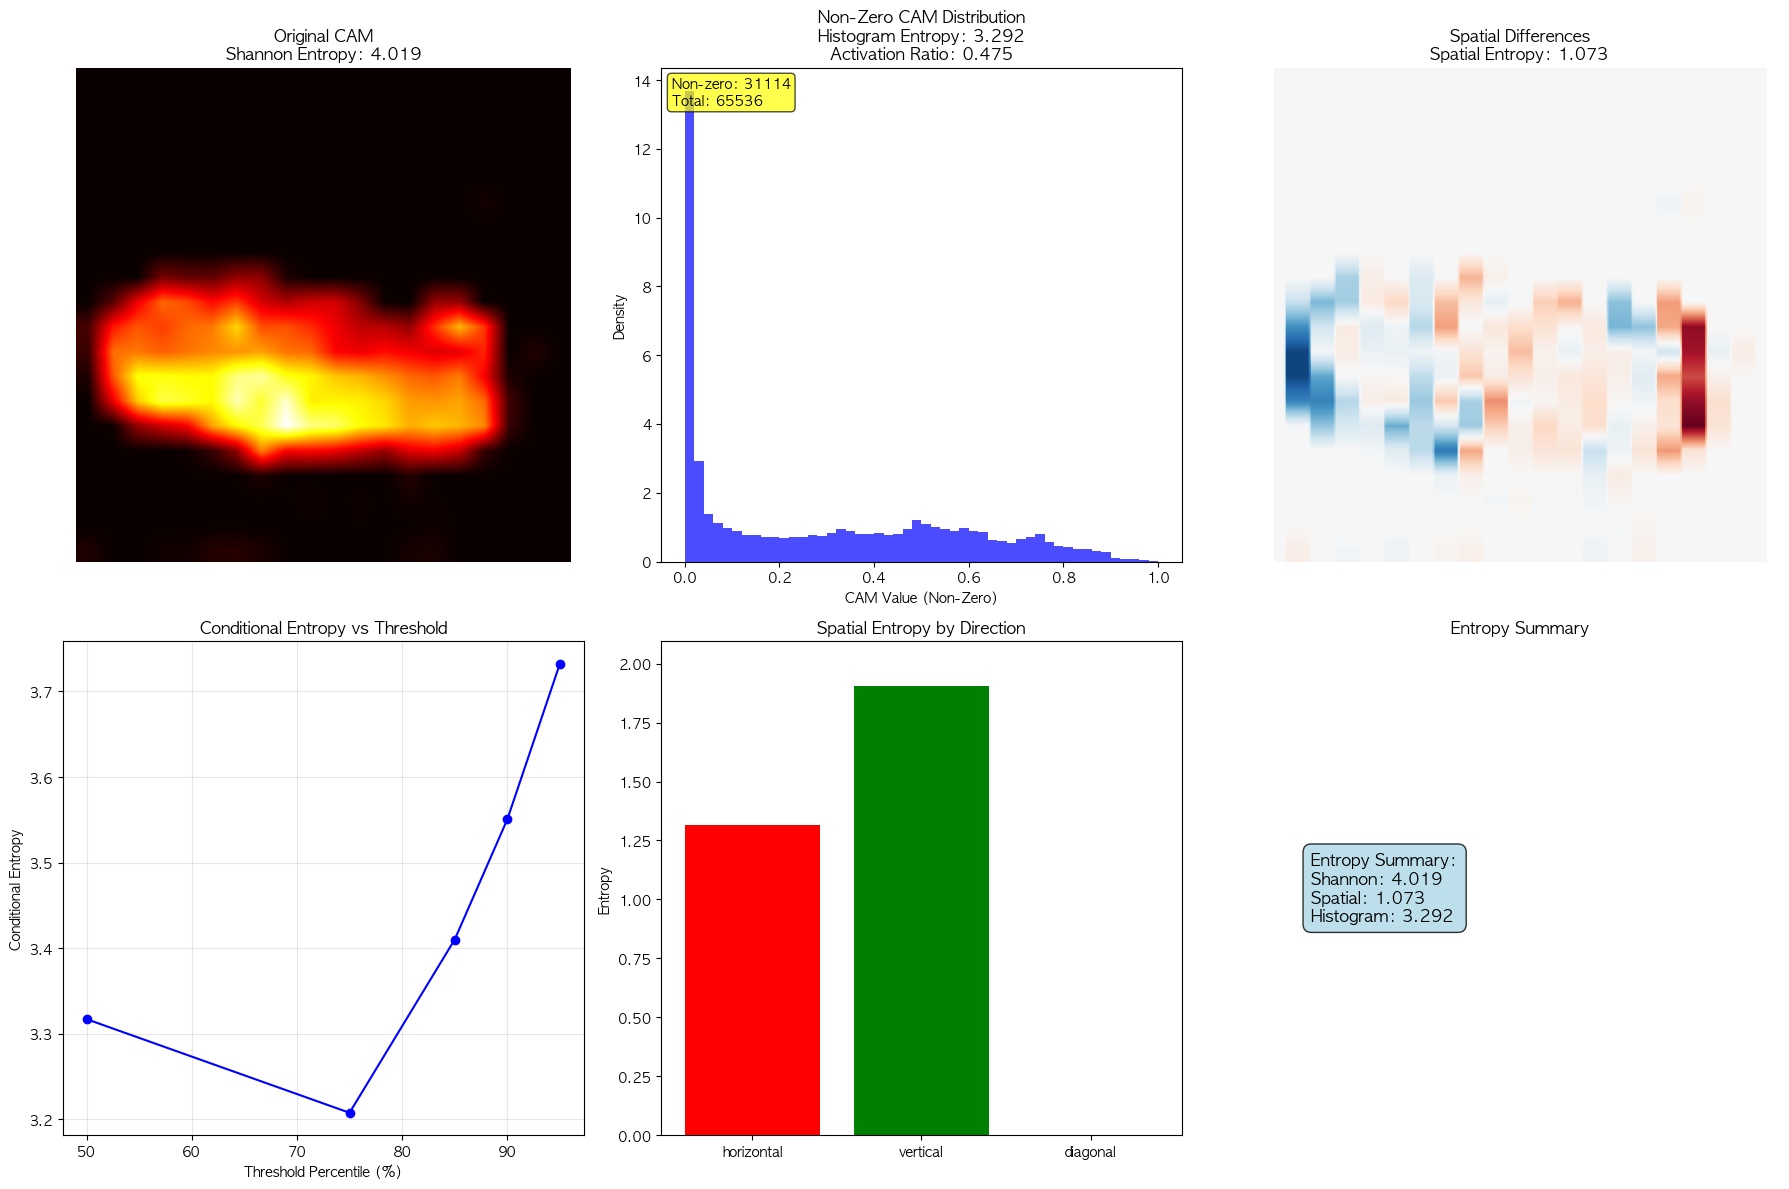

In [35]:
# 엔트로피 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 원본 CAM
axes[0, 0].imshow(grayscale_cam, cmap='hot')
axes[0, 0].set_title(f'Original CAM\nShannon Entropy: {entropy_results["shannon"]:.3f}')
axes[0, 0].axis('off')

# 2. 개선된 히스토그램 (0값 제외)
non_zero_cam = grayscale_cam.flatten()[grayscale_cam.flatten() > 0]

if len(non_zero_cam) > 0:
    axes[0, 1].hist(non_zero_cam, bins=50, alpha=0.7, color='blue', density=True)
    axes[0, 1].set_title(f'Non-Zero CAM Distribution\nHistogram Entropy: {entropy_results["histogram"]:.3f}\nActivation Ratio: {entropy_results["activation_ratio"]:.3f}')
    axes[0, 1].set_xlabel('CAM Value (Non-Zero)')
    axes[0, 1].set_ylabel('Density')
    
    # 활성화 비율 정보 추가
    axes[0, 1].text(0.02, 0.98, f'Non-zero: {entropy_results["non_zero_count"]}\nTotal: {len(grayscale_cam.flatten())}', 
                    transform=axes[0, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
else:
    axes[0, 1].text(0.5, 0.5, 'No Activation\n(All values are 0)', 
                    transform=axes[0, 1].transAxes, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.7))
    axes[0, 1].set_title('No Non-Zero Values')

# 3. 공간적 차이 시각화
h_diff = np.diff(grayscale_cam, axis=1)
axes[0, 2].imshow(h_diff, cmap='RdBu', vmin=-np.max(np.abs(h_diff)), vmax=np.max(np.abs(h_diff)))
axes[0, 2].set_title(f'Spatial Differences\nSpatial Entropy: {entropy_results["spatial"]:.3f}')
axes[0, 2].axis('off')

# 4. 임계값별 조건부 엔트로피
if 'conditional' in entropy_results:
    thresholds = list(entropy_results['conditional'].keys())
    conditional_ents = list(entropy_results['conditional'].values())
    axes[1, 0].plot(thresholds, conditional_ents, 'bo-')
    axes[1, 0].set_xlabel('Threshold Percentile (%)')
    axes[1, 0].set_ylabel('Conditional Entropy')
    axes[1, 0].set_title('Conditional Entropy vs Threshold')
    axes[1, 0].grid(True, alpha=0.3)

# 5. 공간적 방향별 엔트로피
if 'spatial_directions' in entropy_results:
    directions = list(entropy_results['spatial_directions'].keys())
    direction_ents = list(entropy_results['spatial_directions'].values())
    axes[1, 1].bar(directions, direction_ents, color=['red', 'green', 'blue'])
    axes[1, 1].set_ylabel('Entropy')
    axes[1, 1].set_title('Spatial Entropy by Direction')
    axes[1, 1].set_ylim(0, max(direction_ents) * 1.1)

# 6. 엔트로피 요약
entropy_summary = f"""Entropy Summary:
Shannon: {entropy_results['shannon']:.3f}
Spatial: {entropy_results['spatial']:.3f}
Histogram: {entropy_results['histogram']:.3f}"""

axes[1, 2].text(0.1, 0.5, entropy_summary, transform=axes[1, 2].transAxes, 
                fontsize=12, verticalalignment='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
axes[1, 2].set_title('Entropy Summary')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [36]:
# 엔트로피 해석
print(f"\n=== 엔트로피 해석 ===")
shannon_ent = entropy_results['shannon']
spatial_ent = entropy_results['spatial']
hist_ent = entropy_results['histogram']

print(f"1. Shannon 엔트로피 ({shannon_ent:.3f}):")
if shannon_ent > 6.0:
    print("   - 매우 높음: CAM이 매우 복잡하고 다양한 정보를 포함")
elif shannon_ent > 4.0:
    print("   - 높음: CAM이 상당한 복잡성을 가짐")
elif shannon_ent > 2.0:
    print("   - 보통: CAM이 적당한 복잡성을 가짐")
else:
    print("   - 낮음: CAM이 단순하고 일관된 패턴을 가짐")

print(f"\n2. 공간적 엔트로피 ({spatial_ent:.3f}):")
if spatial_ent > 5.0:
    print("   - 매우 높음: 공간적으로 매우 불규칙한 패턴")
elif spatial_ent > 3.0:
    print("   - 높음: 공간적으로 복잡한 패턴")
else:
    print("   - 낮음: 공간적으로 규칙적이고 부드러운 패턴")

print(f"\n3. 히스토그램 엔트로피 ({hist_ent:.3f}):")
if hist_ent > 3.0:
    print("   - 높음: 활성도 값이 매우 다양하게 분포")
elif hist_ent > 1.5:
    print("   - 보통: 활성도 값이 적당히 분포")
else:
    print("   - 낮음: 활성도 값이 특정 범위에 집중")

# 엔트로피 기반 CAM 품질 평가
print(f"\n4. CAM 품질 평가:")
if shannon_ent > 4.0 and spatial_ent > 3.0:
    print("   - CAM이 복잡하고 정보가 풍부함 (높은 품질)")
elif shannon_ent < 2.0 and spatial_ent < 2.0:
    print("   - CAM이 단순하고 정보가 부족함 (낮은 품질)")
else:
    print("   - CAM이 적당한 복잡성을 가짐 (보통 품질)")


=== 엔트로피 해석 ===
1. Shannon 엔트로피 (4.019):
   - 높음: CAM이 상당한 복잡성을 가짐

2. 공간적 엔트로피 (1.073):
   - 낮음: 공간적으로 규칙적이고 부드러운 패턴

3. 히스토그램 엔트로피 (3.292):
   - 높음: 활성도 값이 매우 다양하게 분포

4. CAM 품질 평가:
   - CAM이 적당한 복잡성을 가짐 (보통 품질)
